## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdullah Rana

**Date:** October 2nd, 2026

# Q1. Regression, Classification, and Model Evaluation Concepts

### Q1.1 - Regression vs. classification

Regression predicts a numeric outcome, like a price or a temperature, where the values have an order and the distance between them means something. Classification predicts a categorical outcome, like which of five mine types is buried somewhere, where the values are labels with no distance between them. Missing a price by $10 is better than missing it by $1,000, but predicting mine type 4 when the truth is 5 is not "closer" than predicting type 1.

That changes how the model predicts and how it is scored. In $k$-NN regression the prediction is the average of the neighbours' values and performance is measured with SSE or RMSE. In $k$-NN classification the prediction is the most common label among the neighbours and performance is measured with accuracy and a confusion table. The target decides which problem it is, not how it is stored. `mine_type` is an integer, but it is still a class label, and averaging it would give meaningless predictions like "type 2.6".

### Q1.2 - Confusion tables

A confusion table cross-tabulates actual class labels against predicted class labels, usually on the test set. The diagonal counts the correct predictions, and each off-diagonal cell counts one specific mistake, like "actual anti-personnel mine, predicted no mine."

It shows what a single accuracy number hides. Two models with the same accuracy can make completely different mistakes, and the table shows which classes the model handles well, which ones it confuses with each other, and whether it barely predicts some class at all. Reading across a row gives that class's recall (how many true members were caught), and reading down a column gives its precision (how often that prediction is right). This matters most when errors have different costs. For a mine detector, calling a mine empty is far worse than a false alarm, and only the confusion table separates the two.

### Q1.3 - What SSE quantifies

SSE is $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$, the sum of the squared differences between the actual values and the model's predictions. It measures the total prediction error of a regression model on a given set of data, so a lower SSE means predictions closer to the truth.

Squaring keeps over- and under-predictions from cancelling out, but it also means SSE says nothing about which direction the model misses in, and it weights big errors much more than small ones, which makes it sensitive to outliers. Because it is a sum in squared units, it grows with $n$ and is only comparable between models scored on the same data (MSE and RMSE fix this). It also depends on where it is computed. On the training data it measures fit, and $k$-NN with $k=1$ gets a training SSE of 0 by construction. On the test data it measures how well the model predicts new observations, which is what we actually care about.

### Q1.4 - Overfitting and underfitting

Overfitting is when a model is flexible enough to learn the noise in the training data along with the real pattern, so it looks great on the training data and does poorly on new data. Underfitting is when a model is too rigid to capture the real pattern, so it does poorly on both.

In $k$-NN, $k$ controls this. With $k=1$, each training point is its own neighbour, so training accuracy is 100%, but every prediction rests on one possibly noisy observation. As $k$ increases, predictions average over more neighbours and get smoother, until $k=n$ predicts the majority class for everything and ignores the features entirely. A big gap between training and test performance signals overfitting, poor performance on both signals underfitting, and the best $k$ is where test performance peaks.

### Q1.5 - Train/test splitting and choosing $k$

The goal is to predict new data, and training performance cannot measure that. Choosing $k$ by training accuracy or SSE would always pick $k=1$, since every point is its own nearest neighbour, and that is the most overfit choice possible. A held-out test set acts as a stand-in for new data, so the $k$ with the best test performance is the one that generalizes instead of memorizing.

The catch is that once the test set is used to choose $k$, it is no longer completely independent. The best test score out of many is partly luck on that split, so it is a little optimistic, and on small data a different split can even pick a different $k$. A cleaner approach is a separate validation set or cross-validation on the training data, with the test set used once at the end. I follow the assignment here and choose $k$ on the test set, but I check how stable that choice is in Q2.3.

### Q1.6 - Class labels vs. probability distributions

A class label is simple to act on, easy to communicate, and easy to score with accuracy and a confusion table. Its weakness is that it throws away confidence. A unanimous 3–0 vote and a 2–1 vote produce the same label, and the "pick the most likely class" rule is built in, which treats every mistake as equally costly.

A probability distribution, like 60% no mine and 40% anti-personnel, keeps that information. It shows when the model is unsure, allows cases to be ranked by risk, and lets the user pick a threshold that reflects the real costs, like treating a spot as dangerous whenever the chance of any mine is above 10%. The downsides are that it is harder to communicate and evaluate, a decision rule is still needed in the end, and poorly calibrated probabilities can be misleading. $k$-NN probabilities are also coarse: with $k=3$ they can only be 0, 1/3, 2/3, or 1.

# Q2. $k$-NN Classification: Land Mines

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Mine type names from the UCI documentation for this dataset (Yilmaz et al., 2018)
MINE_NAMES = {1: 'Null (no mine)', 2: 'Anti-tank', 3: 'Anti-personnel',
              4: 'Booby-trapped AP', 5: 'M14 AP'}

### Q2.1 - Load the data and EDA

In [2]:
df = pd.read_csv('./data/land_mines.csv')

print(df.shape)
print('missing values:', df.isnull().sum().sum())
df.head()

(338, 4)
missing values: 0


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [3]:
# Target label
print(df['mine_type'].value_counts().sort_index())
print('majority-class baseline:', round(df['mine_type'].value_counts().max() / len(df), 3))

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
majority-class baseline: 0.21


In [4]:
# Features
print(df[['voltage', 'height', 'soil']].describe().round(3))
print()
print(df.groupby('mine_type')[['voltage', 'height', 'soil']].mean().round(3))

       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000

           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


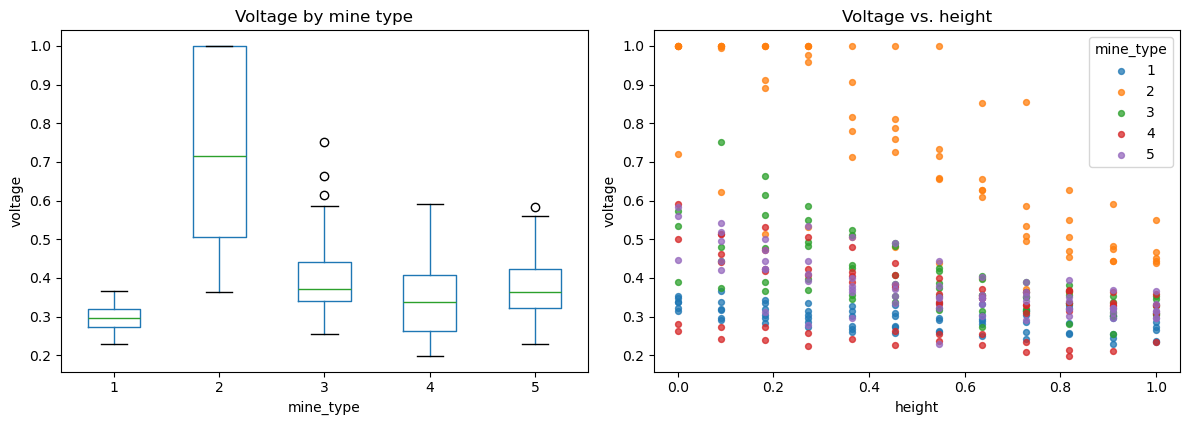

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df.boxplot(column='voltage', by='mine_type', ax=axes[0], grid=False)
axes[0].set_title('Voltage by mine type')
axes[0].set_xlabel('mine_type')
axes[0].set_ylabel('voltage')

for m in sorted(df['mine_type'].unique()):
    sub = df[df['mine_type'] == m]
    axes[1].scatter(sub['height'], sub['voltage'], s=18, alpha=0.75, label=m)
axes[1].set_xlabel('height')
axes[1].set_ylabel('voltage')
axes[1].set_title('Voltage vs. height')
axes[1].legend(title='mine_type')

plt.suptitle('')
plt.tight_layout()
plt.show()

The data have 338 rows and 4 columns with no missing values. `mine_type` is stored as an integer from 1 to 5, but it is a class label (per the UCI documentation: no mine, anti-tank, anti-personnel, booby-trapped anti-personnel, and M14 anti-personnel). The classes are nearly balanced at 65 to 71 rows each, so always guessing the most common class would only be right 21% of the time. That is the baseline to beat.

All three features are already scaled from 0 to 1, so I did not rescale them. `voltage` is the reading from a magnetic sensor, `height` is the sensor's distance from the ground, and `soil` codes six soil types, so even though it is stored as a number it is really a category. Height and soil average about 0.49 to 0.53 in every class, so on their own they say almost nothing about mine type. Voltage is where the signal is. Anti-tank mines stand out with a mean of 0.721 against 0.30 to 0.40 for everything else, and "no mine" has the lowest and tightest readings. The three anti-personnel types overlap heavily with each other and with the no-mine range.

The scatter plot shows that height still matters through voltage, since readings drop as the sensor is raised. Anti-tank readings fall from 1.0 near the ground to around 0.5 at the top heights, where they start to overlap the anti-personnel range. Based on this, I expect anti-tank to be easy to classify and the three anti-personnel types to be hard to tell apart.

### Q2.2 - 50/50 train/test split

In [6]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

print('train:', X_train.shape, ' test:', X_test.shape)
print(pd.DataFrame({'train': y_train.value_counts().sort_index(),
                    'test': y_test.value_counts().sort_index()}))

train: (169, 3)  test: (169, 3)
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32


I split the data 50/50 into 169 training and 169 test rows. I used `stratify=y` so both halves keep the same class proportions, since with only 65 to 71 rows per class a purely random split could leave one class short in one half. Every class ends up with 32 to 36 rows on each side, and `random_state=100` makes the split reproducible.

### Q2.3 - Build the $k$-NN classifier and choose $k$

In [7]:
k_grid = range(1, 51)
train_acc, test_acc = [], []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

acc = pd.DataFrame({'train': train_acc, 'test': test_acc}, index=list(k_grid))
print(acc.head(10).round(3))
print()
print('best k on test set:', acc['test'].idxmax(), ' accuracy:', round(acc['test'].max(), 3))

    train   test
1   1.000  0.343
2   0.704  0.396
3   0.663  0.432
4   0.633  0.355
5   0.598  0.331
6   0.586  0.337
7   0.580  0.396
8   0.544  0.379
9   0.503  0.379
10  0.533  0.367

best k on test set: 3  accuracy: 0.432


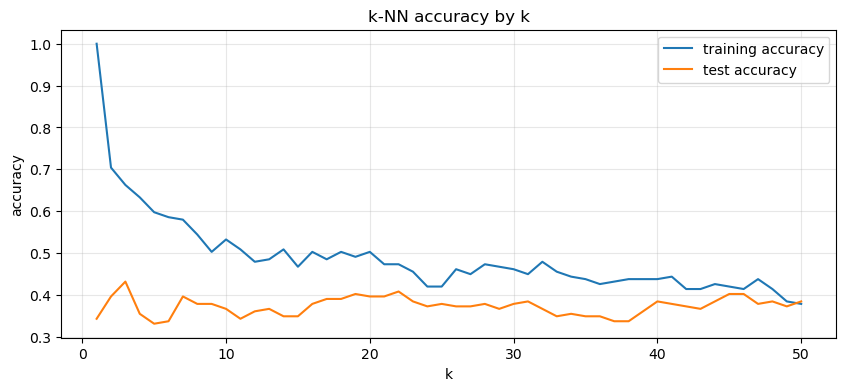

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(acc.index, acc['train'], label='training accuracy')
plt.plot(acc.index, acc['test'], label='test accuracy')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('k-NN accuracy by k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
k_best = int(acc['test'].idxmax())
knn = KNeighborsClassifier(n_neighbors=k_best).fit(X_train, y_train)
y_pred = knn.predict(X_test)

I fit a $k$-NN classifier on the training set for every $k$ from 1 to 50 and compared training and test accuracy. At $k=1$ training accuracy is 100% but test accuracy is only 34.3%, which is overfitting. As $k$ grows the gap closes, and test accuracy peaks at $k=3$ with 43.2% before leveling off between about 33% and 41%, where the model starts underfitting. I chose $k=3$ since it has the highest test accuracy.

Since $k$ was picked using the test set, the 43.2% is probably a little optimistic for new data.

### Q2.4 - Confusion table for the optimal model

In [10]:
print(pd.crosstab(y_test, y_pred, rownames=['actual'], colnames=['predicted']))
print()
print('accuracy:', round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, digits=3))

predicted   1   2   3  4  5
actual                     
1          24   0   6  3  3
2           1  29   2  2  1
3          15   3   8  1  6
4          10   4  10  8  1
5          14   1  12  1  4

accuracy: 0.432

              precision    recall  f1-score   support

           1      0.375     0.667     0.480        36
           2      0.784     0.829     0.806        35
           3      0.211     0.242     0.225        33
           4      0.533     0.242     0.333        33
           5      0.267     0.125     0.170        32

    accuracy                          0.432       169
   macro avg      0.434     0.421     0.403       169
weighted avg      0.438     0.432     0.410       169



The model is correct on 73 of 169 test cases, an accuracy of 43.2%. That is about twice the 21% baseline, but it is still wrong more often than right, and performance is very uneven across classes.

Anti-tank mines (class 2) are the clear strength, with 29 of 35 identified (82.9% recall) and only one called "no mine." "No mine" (class 1) also has decent recall at 24 of 36. The three anti-personnel types are close to guessing, with recall of 24.2% for classes 3 and 4 and 12.5% for class 5. Most of their errors go to each other or to "no mine," which is exactly where the voltage distributions overlapped in the EDA. The biggest problem is the "no mine" column: the model predicts it 64 times, and only 24 of those are actually empty, so 40 real mines are labelled as no mine.

### Q2.5 - How to use this model in practice

In [11]:
# Collapse to the decision that matters: mine vs. no mine (class 1)
actual_mine = y_test != 1
pred_mine = y_pred != 1
print(pd.crosstab(actual_mine, pred_mine, rownames=['actual mine'], colnames=['predicted mine']))

predicted mine  False  True 
actual mine                 
False              24     12
True               40     93


Collapsing the table to mine versus no mine, the model misses 40 of 133 real mines, and when it says "no mine" it is wrong 62.5% of the time. A false alarm costs time, but a missed mine can kill someone, so this model should never be used to declare ground safe. I would treat every "no mine" prediction as not yet cleared and keep the normal clearance process everywhere.

Where the model is useful is triage. Anti-tank predictions are reliable (about 83% recall and 78% precision), so those spots can be flagged for anti-tank procedures right away. The model cannot reliably tell the three anti-personnel types apart, so if deminers handle them with similar precautions, it would make more sense to report a single "anti-personnel" prediction than a subtype the model cannot distinguish. I would also look at the predicted probabilities instead of only the label, and only treat a spot as low-risk if all the neighbours agree there is no mine. Before using it in the field, it would need to be tested on real minefield data, since 338 controlled readings do not include things like metal debris or mixed soils.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [12]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]